# CD_A noepoch: single run vs multi-restart

在随机 ER 图上比较 `dag_coordinate_descent_l0`（单次运行）和
`dag_coordinate_descent_l0_multi`（多重启取最优 score），
均为非早停版本，对比 SHD、score 和 runtime。

核心假设：score 与 SHD 正相关，因此多次运行取最小 score 可间接改善 SHD。

In [6]:
import os
import sys
import time
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'synthetic_dataset.py').exists() and (candidate / 'coordinate_descent').exists():
            return candidate
    raise RuntimeError('Cannot locate repo root from current working directory.')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from synthetic_dataset import SyntheticDataset
from MEC import is_in_markov_equiv_class
from coordinate_descent.coordinate0 import (
    dag_coordinate_descent_l0 as cd_A_single,
    dag_coordinate_descent_l0_multi as cd_A_multi,
    f as cd_A_objective,
)

print('REPO_ROOT =', REPO_ROOT)

REPO_ROOT = C:\Users\super\DAG


In [7]:
CFG = {
    'n_trials': 30,
    'dataset_seeds': list(range(1, 4)),  # 10 random ER graphs
    'algo_master_seed': 20260407,
    'n_samples': 50000,
    'd': 30,
    'degree': 2.0,
    'noise_type': 'gaussian_nv',
    'b_scale': 1.0,
    'threshold': 0.05,
    'lambda_l0': 0.2,
    # per-run iteration budget
    'T': 50000,
    # multi-restart: n_restarts choices to test
    'n_restarts_list': [3, 5, 10],
    'early_stop': True,
    'save_results': True,
}
CFG

{'n_trials': 30,
 'dataset_seeds': [1, 2, 3],
 'algo_master_seed': 20260407,
 'n_samples': 50000,
 'd': 30,
 'degree': 2.0,
 'noise_type': 'gaussian_nv',
 'b_scale': 1.0,
 'threshold': 0.05,
 'lambda_l0': 0.2,
 'T': 50000,
 'n_restarts_list': [3, 5, 10],
 'early_stop': True,
 'save_results': True}

In [8]:
def weight_to_binary_adj(W: np.ndarray, threshold: float = 0.05) -> np.ndarray:
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G


def shd_score(G_true: np.ndarray, G_est: np.ndarray) -> int:
    return int(np.sum(np.abs(np.asarray(G_true, int) - np.asarray(G_est, int))))


def run_single(S, G_true, seed, cfg):
    t0 = time.perf_counter()
    A_est, G_est, score_end = cd_A_single(
        S, T=cfg['T'], seed=int(seed),
        threshold=cfg['threshold'], lambda_l0=cfg['lambda_l0'],
        early_stop=cfg['early_stop'],
    )
    runtime = time.perf_counter() - t0
    return {
        'score': float(score_end),
        'shd': shd_score(G_true, G_est),
        'n_edges_est': int(G_est.sum()),
        'runtime_sec': runtime,
        'mec_match': int(is_in_markov_equiv_class(G_true, G_est)),
    }


def run_multi(S, G_true, seed, cfg, n_restarts):
    t0 = time.perf_counter()
    A_est, G_est, score_end = cd_A_multi(
        S, T=cfg['T'], seed=int(seed),
        threshold=cfg['threshold'], lambda_l0=cfg['lambda_l0'],
        n_restarts=n_restarts,early_stop=cfg['early_stop'],
    )
    runtime = time.perf_counter() - t0
    return {
        'score': float(score_end),
        'shd': shd_score(G_true, G_est),
        'n_edges_est': int(G_est.sum()),
        'runtime_sec': runtime,
        'mec_match': int(is_in_markov_equiv_class(G_true, G_est)),
    }

In [9]:
rng = np.random.default_rng(CFG['algo_master_seed'])
algo_seeds = rng.integers(0, 10**9, size=CFG['n_trials'])

# mode labels: 'single', 'multi_3', 'multi_5', 'multi_10'
modes = ['single'] + [f'multi_{k}' for k in CFG['n_restarts_list']]

rows = []
for ds_seed in CFG['dataset_seeds']:
    dataset = SyntheticDataset(
        n=CFG['n_samples'], d=CFG['d'], graph_type='ER', degree=CFG['degree'],
        noise_type=CFG['noise_type'], B_scale=CFG['b_scale'], seed=ds_seed,
    )
    S = dataset.X.T @ dataset.X / dataset.X.shape[0]
    B_true = np.asarray(dataset.B, dtype=float)
    G_true = weight_to_binary_adj(B_true, threshold=0.0)
    n_edges_true = int(G_true.sum())
    print(f'\n=== dataset seed={ds_seed}, d={CFG["d"]}, true_edges={n_edges_true} ===')

    for trial_id, aseed in enumerate(algo_seeds, 1):
        # single run
        m_single = run_single(S, G_true, aseed, CFG)
        rows.append({
            'dataset_seed': ds_seed, 'trial_id': trial_id, 'algo_seed': int(aseed),
            'mode': 'single', 'n_restarts': 1, 'n_edges_true': n_edges_true, **m_single,
        })

        # multi-restart runs
        for k in CFG['n_restarts_list']:
            m_multi = run_multi(S, G_true, aseed, CFG, n_restarts=k)
            rows.append({
                'dataset_seed': ds_seed, 'trial_id': trial_id, 'algo_seed': int(aseed),
                'mode': f'multi_{k}', 'n_restarts': k, 'n_edges_true': n_edges_true, **m_multi,
            })

        if trial_id <= 2 or trial_id % 10 == 0:
            latest = {r['mode']: r for r in rows[-len(modes):]}
            parts = []
            for mode in modes:
                r = latest[mode]
                parts.append(f"{mode}: shd={r['shd']:2d} score={r['score']:.3f} rt={r['runtime_sec']:.1f}s")
            print(f"  trial {trial_id:3d}  " + '  |  '.join(parts))

df = pd.DataFrame(rows)
print(f'\nTotal rows: {len(df)}')
display(df.head(8))


=== dataset seed=1, d=30, true_edges=38 ===
  trial   1  single: shd=58 score=60.958 rt=8.5s  |  multi_3: shd=55 score=58.314 rt=26.7s  |  multi_5: shd=55 score=58.314 rt=49.7s  |  multi_10: shd=55 score=58.314 rt=127.4s
  trial   2  single: shd=41 score=59.043 rt=11.7s  |  multi_3: shd=36 score=58.593 rt=40.7s  |  multi_5: shd=36 score=58.593 rt=79.0s  |  multi_10: shd=55 score=58.448 rt=146.0s
  trial  10  single: shd=41 score=59.215 rt=11.1s  |  multi_3: shd=38 score=58.360 rt=33.8s  |  multi_5: shd=38 score=58.360 rt=53.5s  |  multi_10: shd=38 score=58.121 rt=110.8s
  trial  20  single: shd=46 score=58.881 rt=10.5s  |  multi_3: shd=45 score=58.287 rt=34.0s  |  multi_5: shd=45 score=58.287 rt=60.2s  |  multi_10: shd=45 score=58.287 rt=107.6s
  trial  30  single: shd=41 score=58.639 rt=10.4s  |  multi_3: shd=44 score=58.517 rt=28.4s  |  multi_5: shd=31 score=58.273 rt=47.6s  |  multi_10: shd=31 score=58.273 rt=102.8s

=== dataset seed=2, d=30, true_edges=31 ===
  trial   1  single: 

,dataset_seed,trial_id,algo_seed,mode,n_restarts,n_edges_true,score,shd,n_edges_est,runtime_sec,mec_match
0,1,1,18044244,single,1,38,60.958322,58,52,8.524709,0
1,1,1,18044244,multi_3,3,38,58.313786,55,51,26.743325,0
2,1,1,18044244,multi_5,5,38,58.313786,55,51,49.705747,0
3,1,1,18044244,multi_10,10,38,58.313786,55,51,127.360862,0
4,1,2,604916791,single,1,38,59.043080,41,43,11.730404,0
5,1,2,604916791,multi_3,3,38,58.593140,36,44,40.665752,0
6,1,2,604916791,multi_5,5,38,58.593140,36,44,78.956705,0
7,1,2,604916791,multi_10,10,38,58.447739,55,55,146.029983,0


In [10]:
summary = (
    df.groupby('mode', as_index=False)
    .agg(
        trials=('shd', 'size'),
        shd_mean=('shd', 'mean'),
        shd_std=('shd', 'std'),
        shd_median=('shd', 'median'),
        score_mean=('score', 'mean'),
        score_std=('score', 'std'),
        runtime_mean=('runtime_sec', 'mean'),
        runtime_std=('runtime_sec', 'std'),
        mec_rate=('mec_match', 'mean'),
    )
)
# reorder rows: single first, then multi_3, multi_5, multi_10
mode_order = {m: i for i, m in enumerate(modes)}
summary['_order'] = summary['mode'].map(mode_order)
summary = summary.sort_values('_order').drop(columns='_order').reset_index(drop=True)

print('Overall summary:')
display(summary)

Overall summary:


,mode,trials,shd_mean,shd_std,shd_median,score_mean,score_std,runtime_mean,runtime_std,mec_rate
0,single,90,31.144444,11.056099,28.5,57.067327,1.958745,10.651641,3.086089,0.0
1,multi_3,90,29.044444,9.724186,29.0,56.384099,1.593353,30.936180,7.380911,0.0
2,multi_5,90,27.500000,10.865108,27.5,56.204497,1.597699,51.865101,11.852217,0.0
3,multi_10,90,25.300000,10.216147,24.0,55.954776,1.605487,104.239988,23.378860,0.0


In [11]:
# Paired comparison: same (dataset_seed, algo_seed)
df_single = df[df['mode'] == 'single'].set_index(['dataset_seed', 'algo_seed'])

print('Paired comparison vs single run:\n')
for k in CFG['n_restarts_list']:
    mode = f'multi_{k}'
    df_m = df[df['mode'] == mode].set_index(['dataset_seed', 'algo_seed'])
    paired = df_single[['shd', 'score', 'runtime_sec']].join(
        df_m[['shd', 'score', 'runtime_sec']], lsuffix='_single', rsuffix='_multi'
    )
    paired['shd_diff'] = paired['shd_multi'] - paired['shd_single']
    paired['score_diff'] = paired['score_multi'] - paired['score_single']
    n_better = (paired['shd_diff'] < 0).sum()
    n_same   = (paired['shd_diff'] == 0).sum()
    n_worse  = (paired['shd_diff'] > 0).sum()
    print(
        f"  {mode:10s}: "
        f"SHD diff mean={paired['shd_diff'].mean():+.2f}, "
        f"median={paired['shd_diff'].median():+.1f}  "
        f"(better={n_better}, same={n_same}, worse={n_worse})  "
        f"score diff={paired['score_diff'].mean():+.4f}  "
        f"runtime ratio={paired['runtime_sec_multi'].mean() / paired['runtime_sec_single'].mean():.1f}x"
    )

Paired comparison vs single run:

  multi_3   : SHD diff mean=-2.10, median=-2.0  (better=53, same=3, worse=34)  score diff=-0.6832  runtime ratio=2.9x
  multi_5   : SHD diff mean=-3.64, median=-4.0  (better=59, same=2, worse=29)  score diff=-0.8628  runtime ratio=4.9x
  multi_10  : SHD diff mean=-5.84, median=-4.5  (better=68, same=1, worse=21)  score diff=-1.1126  runtime ratio=9.8x


C:\Users\super\AppData\Local\Temp\ipykernel_16444\2888582833.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_rt, labels=modes, patch_artist=True)


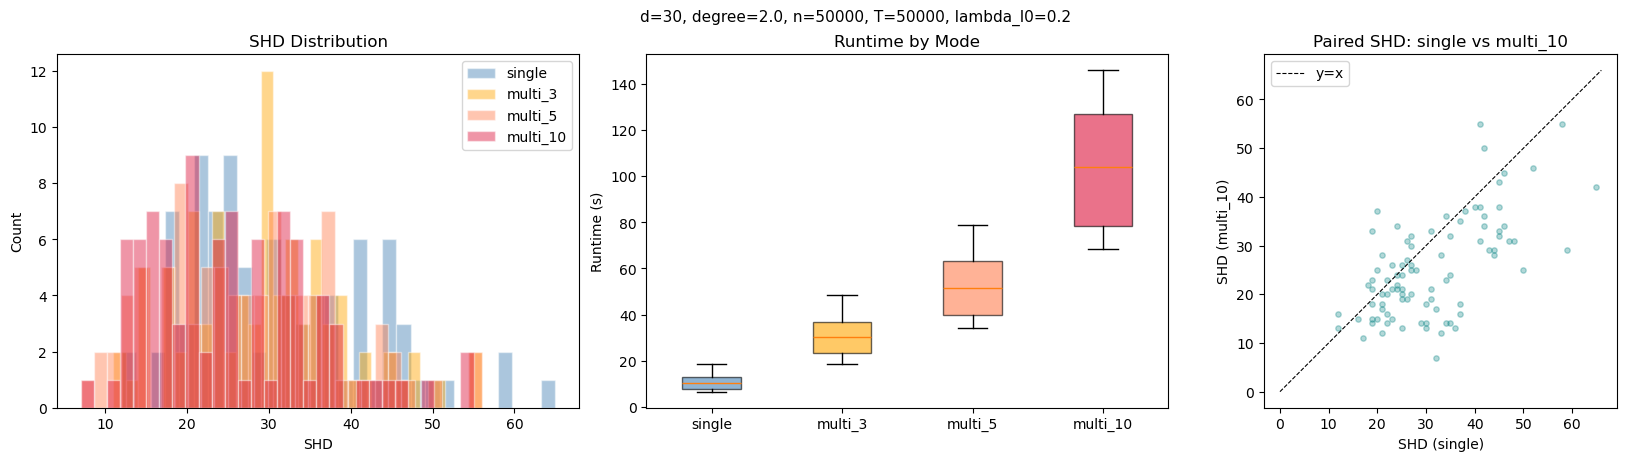

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
colors = {'single': 'steelblue', 'multi_3': 'orange', 'multi_5': 'coral', 'multi_10': 'crimson'}

# 1. SHD distribution
ax = axes[0]
for mode in modes:
    sub = df[df['mode'] == mode]
    ax.hist(sub['shd'], bins=30, alpha=0.45, color=colors[mode], label=mode, edgecolor='white')
ax.set_xlabel('SHD')
ax.set_ylabel('Count')
ax.set_title('SHD Distribution')
ax.legend()

# 2. Runtime comparison (box plot)
ax = axes[1]
data_rt = [df[df['mode'] == m]['runtime_sec'].values for m in modes]
bp = ax.boxplot(data_rt, labels=modes, patch_artist=True)
for patch, mode in zip(bp['boxes'], modes):
    patch.set_facecolor(colors[mode])
    patch.set_alpha(0.6)
ax.set_ylabel('Runtime (s)')
ax.set_title('Runtime by Mode')

# 3. Paired SHD: single vs multi_10
ax = axes[2]
best_multi = f'multi_{CFG["n_restarts_list"][-1]}'
df_s = df[df['mode'] == 'single'].set_index(['dataset_seed', 'algo_seed'])
df_m = df[df['mode'] == best_multi].set_index(['dataset_seed', 'algo_seed'])
paired_plot = df_s[['shd']].join(df_m[['shd']], lsuffix='_single', rsuffix='_multi')
ax.scatter(paired_plot['shd_single'], paired_plot['shd_multi'], alpha=0.3, s=15, color='teal')
lim = max(paired_plot['shd_single'].max(), paired_plot['shd_multi'].max()) + 1
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='y=x')
ax.set_xlabel('SHD (single)')
ax.set_ylabel(f'SHD ({best_multi})')
ax.set_title(f'Paired SHD: single vs {best_multi}')
ax.legend()
ax.set_aspect('equal')

fig.suptitle(
    f'd={CFG["d"]}, degree={CFG["degree"]}, n={CFG["n_samples"]}, T={CFG["T"]}, '
    f'lambda_l0={CFG["lambda_l0"]}',
    fontsize=11,
)
plt.show()

In [13]:
if CFG['save_results']:
    out_dir = REPO_ROOT / 'experiments' / 'results'
    out_dir.mkdir(parents=True, exist_ok=True)

    trials_csv = out_dir / 'cd_A_multi_restart_trials.csv'
    summary_csv = out_dir / 'cd_A_multi_restart_summary.csv'
    df.to_csv(trials_csv, index=False)
    summary.to_csv(summary_csv, index=False)
    print(f'Saved:\n - {trials_csv}\n - {summary_csv}')

Saved:
 - C:\Users\super\DAG\experiments\results\cd_A_multi_restart_trials.csv
 - C:\Users\super\DAG\experiments\results\cd_A_multi_restart_summary.csv
